# **Binary Model**

## Libraries

In [90]:
# Libraries
import sys
import os
import re
import random
import shutil
import math

import pandas as pd
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.image import load_img, img_to_array, smart_resize, ImageDataGenerator

from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, BatchNormalization, Dropout, Lambda, GlobalMaxPooling2D, Concatenate
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC
from focal_loss import BinaryFocalLoss

import optuna

from deep.constants import DATA_DIR, IMAGE_DIR
from deep.preprocessing.label_oversampler import compute_effective_class_weights

In [32]:
# Setting options
pd.set_option('display.max_rows', None)

## Data Loading

In [33]:
# Load the metadata
data = pd.read_csv(f'{DATA_DIR}/metadata.csv')

# Drop unnecessary columns for this problem
data.drop(columns=['phylum', 'family'], inplace=True)

In [34]:
# # Creating a sample
# train_df, sample_df = train_test_split(
#     data,
#     test_size=0.3,
#     stratify=data['family'],
#     random_state=20
# )

## Data Preprocessing

In [35]:
# Performing the splits
train_df, test_df = train_test_split(data, test_size=0.2, stratify=data['is_animal'], random_state=20)  # Create test set
train_df, val_df = train_test_split(train_df, test_size=0.15, stratify=train_df['is_animal'], random_state=20)  # Create validation set

In [36]:
# Load the metadata file with the new cropped images
cropped_df = pd.read_csv(f'{DATA_DIR}/cropped_images.csv')

In [37]:
# Add the new metadata to train_df
train_df = pd.concat([
    train_df
    ,cropped_df
], ignore_index=True
, axis=0
)

In [38]:
# # Encoding the target
# enc = LabelEncoder()

# train_df['family'] = enc.fit_transform(train_df['family'])
# val_df['family'] = enc.transform(val_df['family'])
# test_df['family'] = enc.transform(test_df['family'])

In [39]:
# Image resizing target dimensions
IMG_SIZE = 224
BATCH_SIZE = 8

In [53]:
def smart_resize_img(image, target_size=(IMG_SIZE, IMG_SIZE)):
    resized_img = smart_resize(image, target_size)  # Resize image
    resized_img /= 255.0  # Normalize the image
    
    return resized_img

In [54]:
# # Resizing the images
# label_train_generator = smart_resize_generator(train_df, 'label', batch_size=BATCH_SIZE, target_size=(IMG_SIZE, IMG_SIZE))
# print('train resizing completed')
# label_val_generator = smart_resize_generator(val_df, 'label', batch_size=BATCH_SIZE, target_size=(IMG_SIZE, IMG_SIZE))
# print('validation resizing completed')
# label_test_generator = smart_resize_generator(test_df, 'label', batch_size=BATCH_SIZE, target_size=(IMG_SIZE, IMG_SIZE))
# print('test resizing completed')

In [55]:
# # Transformation functions
# def rotate_right(img): return img.rotate(-90, expand=True)
# def rotate_left(img): return img.rotate(90, expand=True)
# def flip_horizontal(img): return ImageOps.mirror(img)
# def shear(img):
#     shear_transform = transforms.RandomAffine(degrees=0, shear=20)
#     return shear_transform(img)
# def zoom(img):
#     zoom_transform = transforms.RandomAffine(degrees=0, scale=(0.8, 1.5))
#     return zoom_transform(img)


# transformations = {
#     "rotate_right": rotate_right,
#     "rotate_left": rotate_left,
#     "flip": flip_horizontal,
#     # "shear": shear,
#     # "zoom": zoom
# }

# def augment_images(df, output_dir, target_per_class):
#     os.makedirs(output_dir, exist_ok=True)
#     class_counts = df['label'].value_counts()
#     max_count = class_counts.max()

#     # Identify minority classes
#     minority_classes = class_counts[class_counts < max_count].index

#     # List to hold new rows for augmented images
#     augmented_rows = []

#     for label in minority_classes:
#         class_df = df[df['label'] == label]
#         num_to_generate = target_per_class

#         if num_to_generate <= 0:
#             continue

#         label_dir = os.path.join(output_dir, str(label))
#         os.makedirs(label_dir, exist_ok=True)

#         for _ in range(num_to_generate):
#             row = class_df.sample(1).iloc[0]
#             img_path = row['file_path']
#             original_name = img_path[:-4]
#             ext = img_path[-4:]

#             try:
#                 img = Image.open(f'{IMAGE_DIR}/{img_path}')  # .convert('RGB')
#             except Exception as e:
#                 print(f"Error loading {img_path}: {e}")
#                 continue

#             # Apply random transformation
#             transform_name, transform_fn = random.choice(list(transformations.items()))
#             new_img = transform_fn(img)
#             new_filename = f"{original_name}_{transform_name}{ext}"
#             new_img_path = new_filename
#             new_img.save(f'{IMAGE_DIR}/{new_filename}')

#             # Create a new row for the augmented image and append it to augmented_rows
#             new_row = row.copy()
#             new_row['file_path'] = new_img_path  # Update the file path to the new image
#             augmented_rows.append(new_row)

#     # Add augmented rows to the original dataframe
#     augmented_df = pd.DataFrame(augmented_rows)
#     updated_df = pd.concat([df, augmented_df], ignore_index=True)

#     return updated_df

In [56]:
# # Clean created images
# for filename in os.listdir(IMAGE_DIR):
#     # Check if there's any letter in the filename
#     if re.search(r'[a-zA-Z]', filename[:-4]):
#         file_path = os.path.join(IMAGE_DIR, filename)
#         if os.path.isfile(file_path):
#             os.remove(file_path)
#             print(f"Deleted: {file_path}")

In [57]:
## Create augmented images
# updated_df = augment_images(train_df, output_dir=IMAGE_DIR, target_per_class=6500)

In [58]:
def show_augmented_images(generator, num_images=8):
    images, labels = next(generator)

    actual_num = min(num_images, len(images))  # Avoid index errors

    max_cols = 4
    rows = math.ceil(actual_num / max_cols)
    plt.figure(figsize=(max_cols * 3, rows * 3))

    for i in range(actual_num):
        plt.subplot(rows, max_cols, i + 1)
        plt.imshow(images[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [59]:
# # Undersampling the animal images
# class_0_df = train_df[train_df['label'] == 0]
# class_1_df = train_df[train_df['label'] == 1]

# # Downsample class 1 to 1500
# class_1_downsampled = class_1_df.sample(n=1500, random_state=20)

# # Combine them back
# balanced_train_df = pd.concat(
#     [class_0_df, class_1_downsampled]
# ).sample(
#     frac=1.0
#     ,random_state=20
# ).reset_index(drop=True)

In [60]:
train_datagen = ImageDataGenerator(
    rotation_range=90,
    shear_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    channel_shift_range=30.0,
    zoom_range=(0.8, 1.2),
    preprocessing_function=smart_resize_img
)
test_datagen = ImageDataGenerator(preprocessing_function=smart_resize_img)

# Train generator
binary_train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=f'{IMAGE_DIR}',
    x_col='file_path',
    y_col='is_animal',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=True  # shuffle for training
)

# Validation generator
binary_val_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=f'{IMAGE_DIR}',
    x_col='file_path',
    y_col='is_animal',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)

# Test generator
binary_test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=f'{IMAGE_DIR}',
    x_col='file_path',
    y_col='is_animal',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)

Found 9533 validated image filenames.
Found 1439 validated image filenames.
Found 2397 validated image filenames.


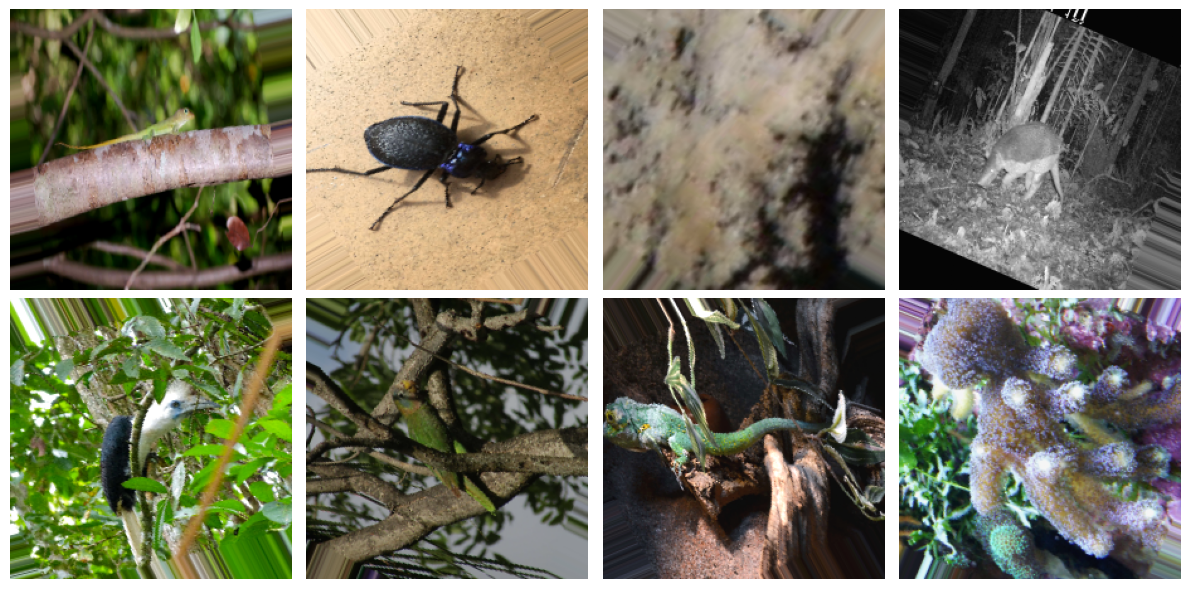

In [61]:
# Show augmented images - rerun for new batch
show_augmented_images(binary_train_generator, num_images=BATCH_SIZE)

## Modelling

In [49]:
## Optuna
# def objective(trial):
#     """
#     Objective function for Optuna hyperparameter optimization.
    
#     Args:
#     - trial (optuna.trial.Trial): The trial object used to sample hyperparameters.
    
#     Returns:
#     - float: The evaluation metric (validation accuracy or other).
#     """
#     lr = trial.suggest_float("lr", 1e-6, 1e-1)
#     optimizer_type = trial.suggest_categorical("optimizer", ["adam", "sgd"])
#     patience = trial.suggest_int("patience", 1, 3)
#     lr_factor = trial.suggest_float("lr_factor", 0.1, 0.7)
#     lr_patience = trial.suggest_int("lr_patience", 1, 5)

#     # Set the input
#     input_tensor = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

#     # Load the pre-trained model
#     base_model = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=input_tensor)

#     # Add necessary layers
#     x = GlobalAveragePooling2D()(base_model.output)
#     output = Dense(1, activation='sigmoid')(x)  # Binary classification

#     binary_model = Model(inputs=input_tensor, outputs=output)

#     # Optimizer setup based on dynamic 'optimizer_type'
#     if optimizer_type == "adam":
#         optimizer = Adam(learning_rate=lr)
#     elif optimizer_type == "sgd":
#         optimizer = SGD(learning_rate=lr)
#     else:
#         raise ValueError(f"Unknown optimizer type: {optimizer_type}")
    
#     # Compiling the model
#     binary_model.compile(
#         optimizer=optimizer,
#         loss='binary_crossentropy',
#         metrics=['accuracy', 'precision', 'recall']
#     )

#     # Fit the model
#     binary_model.fit(
#         binary_train_generator,
#         validation_data=binary_val_generator,
#         epochs=5,
#         steps_per_epoch=int(np.ceil(len(train_df) / BATCH_SIZE)),
#         callbacks=[
#             EarlyStopping(patience=patience, restore_best_weights=True),
#             ReduceLROnPlateau(patience=lr_patience, factor=lr_factor, verbose=1)
#         ],
#         verbose=1
#     )

#     # Evaluate the model using the  validation set
#     _, val_accuracy, _, _ = binary_model.evaluate(binary_val_generator, verbose=0)
    
#     # Return the validation accuracy as the objective metric
#     return val_accuracy

In [50]:
# # Create a study
# study = optuna.create_study(direction="maximize")

# # Optimize the objective function
# study.optimize(lambda trial: objective(trial), n_trials=3)

# # Get the best trial's hyperparameters
# print(f"Best trial: {study.best_trial.params}")

In [95]:
# Build the model

# Set the input
input_tensor = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
# Apply preprocessing to the input tensor
x = Lambda(preprocess_input)(input_tensor)

# Load the pre-trained model
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=x)
# Freeze layers
base_model.trainable = False

# Add top layers
gap = GlobalAveragePooling2D()(x)
gmp = GlobalMaxPooling2D()(x)
x = Concatenate()([gap, gmp])
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)  # Binary classification

binary_model = Model(inputs=input_tensor, outputs=output)

In [96]:
# Compute class weights
class_weights = compute_effective_class_weights(train_df, 'is_animal')

In [97]:
# Compiling the model
binary_model.compile(
    optimizer=Adam(learning_rate=0.01)
    ,loss=BinaryFocalLoss(
        gamma=2
        ,pos_weight=class_weights[1] / (class_weights[0] + class_weights[1])
    )
    # ,loss='binary_crossentropy'
    ,metrics=['accuracy', AUC(), 'precision', 'recall']
)

In [ ]:
# Fit the model
fitted_binary = binary_model.fit(
    binary_train_generator
    ,validation_data=binary_val_generator
    ,epochs=5
    ,steps_per_epoch=int(np.ceil(len(train_df) / BATCH_SIZE))
    ,class_weight=class_weights
    ,callbacks=[
        EarlyStopping(patience=3, restore_best_weights=True)
        ,ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)
    ]
    ,verbose=1
)

Epoch 1/5
1012/1192 ━━━━━━━━━━━━━━━━━━━━ 1:05 365ms/step - accuracy: 0.7244 - auc_10: 0.5050 - loss: 0.1028 - precision: 0.8074 - recall: 0.8645

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


1192/1192 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.7284 - auc_10: 0.5052 - loss: 0.1019 - precision: 0.8057 - recall: 0.8732

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1192/1192 ━━━━━━━━━━━━━━━━━━━━ 515s 430ms/step - accuracy: 0.7284 - auc_10: 0.5052 - loss: 0.1019 - precision: 0.8057 - recall: 0.8733 - val_accuracy: 0.9291 - val_auc_10: 0.5546 - val_loss: 0.0728 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0100
Epoch 2/5
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 548s 460ms/step - accuracy: 0.7762 - auc_10: 0.5101 - loss: 0.0961 - precision: 0.7890 - recall: 0.9762 - val_accuracy: 0.9291 - val_auc_10: 0.4330 - val_loss: 0.0572 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0100
Epoch 3/5
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 549s 460ms/step - accuracy: 0.7877 - auc_10: 0.4806 - loss: 0.0949 - precision: 0.7961 - recall: 0.9857 - val_accuracy: 0.9291 - val_auc_10: 0.4917 - val_loss: 0.0759 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0100
Epoch 4/5
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.7918 - auc_10: 0.5057 - loss: 0.0953 - precision: 0.7920 - recall: 0.9995
Epoch 4: ReduceLROnPlateau reducing 

In [ ]:
# Get the average from model metrics
history = fitted_binary.history
average_metrics = {metric: np.mean(values) for metric, values in history.items()}

for metric, avg in average_metrics.items():
    print(f"{metric}: {avg:.4f}")

In [ ]:
# # Export the model
# binary_model.save('../models/binary_model.keras')

In [ ]:
# # Load the model
# binary_model = load_model('../models/binary_model.keras')

In [ ]:
# Make predictions
predictions = binary_model.predict(
    binary_test_generator
    ,steps=len(binary_test_generator)
    ,verbose=1
)

In [ ]:
# Get the true labels
y_true = binary_test_generator.labels

# Convert predictions to class labels
y_pred = (predictions > 0.5).astype(int).flatten()

# Calculate metrics
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall: {recall_score(y_true, y_pred):.4f}")

In [ ]:
# Get unique values and their counts
unique, counts = np.unique(y_pred, return_counts=True)

# Display the result
value_counts = dict(zip(unique, counts))
print(value_counts)

In [ ]:
# # Save the predictions
# file_paths = binary_test_generator.filenames
# pred_df = pd.DataFrame({
#     'file_path': file_paths,
#     'predictions': (predictions > 0.5).astype(int).flatten()
# })

# # Export to csv
# # pred_df.to_csv('../models/binary_predictions.csv', index=False)